In [1]:
%pip install --upgrade pip
%pip install -q libreyolo matplotlib
%pip install -q --upgrade jupyter ipywidgets


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path


from libreyolo import LibreYOLO
IMAGE_SIZE = 640
BATCH_SIZE = 16


xFormers not available
xFormers not available


In [3]:
model = LibreYOLO("runs/train/yolo9_exp2/weights/best.pt")

In [4]:
import cv2
import numpy as np

video_path = "samples/288312_tiny.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")


In [5]:

# Define a region of interest in image coordinates.
roi_pts = np.array(
    [(3, 278), (489, 290), (492, 403), (3, 393)],
    dtype=np.int32,
)
roi_pts = roi_pts.reshape((-1, 1, 2))

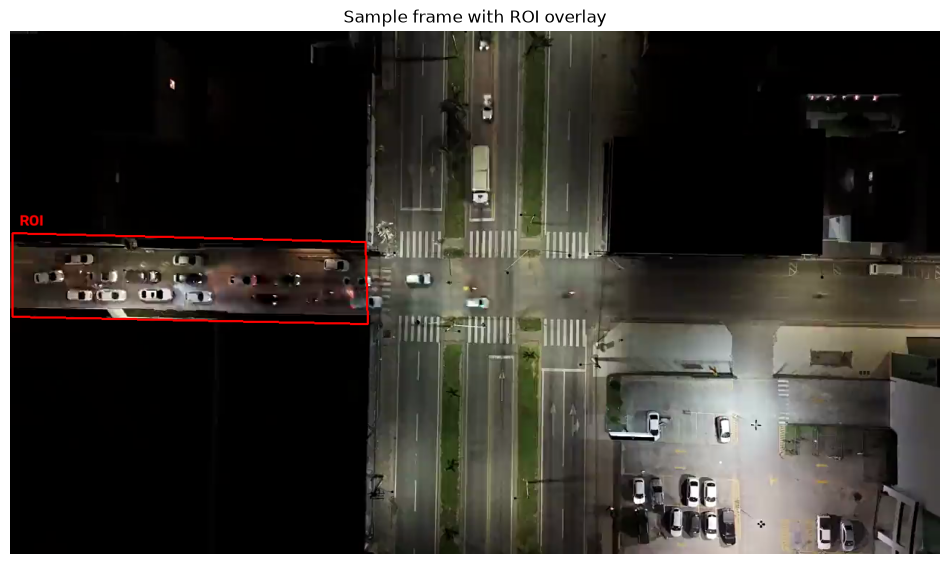

True

In [6]:
import matplotlib.pyplot as plt

# Ensure the video starts from the first frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

success, sample_frame = cap.read()
if not success:
    raise RuntimeError("Could not read a sample frame from the video.")

# Copy and draw the ROI on top of the sample frame
preview = sample_frame.copy()
cv2.polylines(preview, [roi_pts], isClosed=True, color=(0, 0, 255), thickness=2)
cv2.putText(
    preview,
    "ROI",
    (roi_pts[0][0][0] + 10, roi_pts[0][0][1] - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 0, 255),
    2,
)

# Display it in the notebook
preview_rgb = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(preview_rgb)
plt.title("Sample frame with ROI overlay")
plt.axis("off")
plt.show()

# Reset the video so the next cell can process from the beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

In [8]:

from IPython.display import display, clear_output
import matplotlib.pyplot as plt

allowed_classes = {"car", "bus", "lorry", "bicycle"}
counts = {name: 0 for name in sorted(allowed_classes)}

# Track unique object IDs that have already been counted in the ROI
seen_track_ids = set()

# Create a figure for continuous inline rendering
fig, ax = plt.subplots(figsize=(10, 6))

try:
    while True:
        success, frame = cap.read()
        if not success:
            break

        # Track objects across frames with stream=False
        results = model.track(
            source=frame,
            imgsz=IMAGE_SIZE,
            conf=0.25,
            persist=True,
            stream=False,  # Ensures a list of Results is returned, not a generator
            verbose=False,
        )

        result = results[0]
        boxes = getattr(result, "boxes", None)
        names = getattr(result, "names", getattr(model, "names", {}))

        frame_detections = 0

        if boxes is not None and boxes.id is not None:
            xyxy = boxes.xyxy.tolist()
            confs = boxes.conf.tolist()
            class_ids = boxes.cls.tolist()
            track_ids = boxes.id.int().tolist()

            for box, confidence, class_id, track_id in zip(xyxy, confs, class_ids, track_ids):
                class_id = int(class_id)
                class_name = names[class_id] if isinstance(names, (list, tuple)) else names.get(class_id, str(class_id))
                class_name = class_name.lower()

                if class_name not in allowed_classes:
                    continue

                x1, y1, x2, y2 = map(int, box)
                cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0

                # Check if bounding box center point is inside the ROI
                in_roi = cv2.pointPolygonTest(roi_pts, (int(cx), int(cy)), False) >= 0

                if in_roi:
                    frame_detections += 1
                    if track_id not in seen_track_ids:
                        seen_track_ids.add(track_id)
                        counts[class_name] += 1

                # Draw bounding boxes and labels
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    frame,
                    f"#{track_id} {class_name} {confidence:.2f}",
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2,
                )

        # Draw ROI boundary and counts on frame
        cv2.polylines(frame, [roi_pts], isClosed=True, color=(0, 0, 255), thickness=2)
        cv2.putText(
            frame,
            f"In ROI now: {frame_detections} | Total Unique: {sum(counts.values())}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            2,
        )

        # Convert BGR (OpenCV default) to RGB for Matplotlib rendering
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Update Matplotlib plot inline
        ax.clear()
        ax.imshow(frame_rgb)
        ax.axis("off")
        
        display(fig)
        clear_output(wait=True)

finally:
    cap.release()
    plt.close(fig)

print("ROI unique counts by class:", counts)
print("Total unique vehicles in ROI:", sum(counts.values()))

ROI unique counts by class: {'bicycle': 0, 'bus': 0, 'car': 0, 'lorry': 0}
Total unique vehicles in ROI: 0
